# Demand Forecasting Modeling

This notebook develops forecasting models for the top-selling product families.

The workflow includes:

- Time series preparation
- Feature engineering
- Baseline forecasting models
- LightGBM forecasting
- Prophet comparison
- Model evaluation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import lightgbm as lgb

from prophet import Prophet

import joblib

Importing plotly failed. Interactive plots will not work.


In [2]:
df = pd.read_csv("../data/train.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
TOP_FAMILIES = [
    "GROCERY I",
    "BEVERAGES",
    "PRODUCE",
    "CLEANING",
    "DAIRY"
]

In [4]:
family_daily = (
    df
    .groupby(["date", "family"])["sales"]
    .sum()
    .reset_index()
)

family_daily = family_daily[
    family_daily["family"].isin(TOP_FAMILIES)
]

family_daily.head()

,date,family,sales
3,2013-01-01,BEVERAGES,810.0
7,2013-01-01,CLEANING,186.0
8,2013-01-01,DAIRY,143.0
12,2013-01-01,GROCERY I,700.0
30,2013-01-01,PRODUCE,0.0


In [5]:
family_daily.info()

<class 'pandas.DataFrame'>
Index: 8420 entries, 3 to 55569
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    8420 non-null   datetime64[us]
 1   family  8420 non-null   str           
 2   sales   8420 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 263.1 KB


In [6]:
family_daily["family"].value_counts()

family
BEVERAGES    1684
CLEANING     1684
DAIRY        1684
GROCERY I    1684
PRODUCE      1684
Name: count, dtype: int64

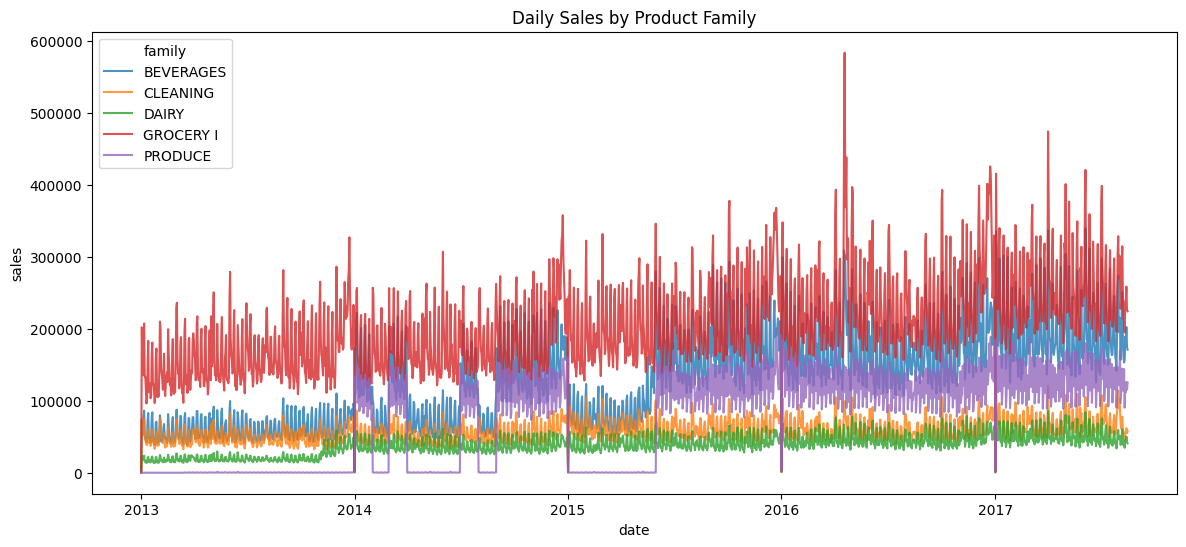

In [7]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=family_daily,
    x="date",
    y="sales",
    hue="family",
    alpha=0.8
)

plt.title("Daily Sales by Product Family")
plt.show()

In [8]:
family_daily = family_daily.sort_values(
    ["family", "date"]
).reset_index(drop=True)

family_daily.head()

,date,family,sales
0,2013-01-01,BEVERAGES,810.0
1,2013-01-02,BEVERAGES,72092.0
2,2013-01-03,BEVERAGES,52105.0
3,2013-01-04,BEVERAGES,54167.0
4,2013-01-05,BEVERAGES,77818.0


In [9]:
family_daily["year"] = family_daily["date"].dt.year
family_daily["month"] = family_daily["date"].dt.month
family_daily["day"] = family_daily["date"].dt.day
family_daily["day_of_week"] = family_daily["date"].dt.dayofweek
family_daily["quarter"] = family_daily["date"].dt.quarter
family_daily["week_of_year"] = family_daily["date"].dt.isocalendar().week.astype(int)
family_daily["is_weekend"] = (
    family_daily["day_of_week"] >= 5
).astype(int)

In [10]:
family_daily["month_sin"] = np.sin(
    2*np.pi*family_daily["month"]/12
)

family_daily["month_cos"] = np.cos(
    2*np.pi*family_daily["month"]/12
)

In [11]:
promotion_daily = (
    df.groupby(["date", "family"])["onpromotion"]
      .sum()
      .reset_index()
)

family_daily = family_daily.merge(
    promotion_daily,
    on=["date", "family"],
    how="left"
)

family_daily["has_promotion"] = (
    family_daily["onpromotion"] > 0
).astype(int)

In [12]:
family_daily["lag_1"] = (
    family_daily
    .groupby("family")["sales"]
    .shift(1)
)

In [13]:
family_daily["lag_7"] = (
    family_daily
    .groupby("family")["sales"]
    .shift(7)
)

In [14]:
family_daily["lag_30"] = (
    family_daily
    .groupby("family")["sales"]
    .shift(30)
)

In [15]:
family_daily["rolling_mean_7"] = (
    family_daily
    .groupby("family")["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [16]:
family_daily["rolling_mean_30"] = (
    family_daily
    .groupby("family")["sales"]
    .transform(
        lambda x: x.shift(1).rolling(30).mean()
    )
)

In [17]:
family_daily.head(15)

,date,family,sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,month_sin,month_cos,onpromotion,has_promotion,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2013-01-01,BEVERAGES,810.0,2013,1,1,1,1,1,0,0.5,0.866025,0,0,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,BEVERAGES,72092.0,2013,1,2,2,1,1,0,0.5,0.866025,0,0,810.0,NaN,NaN,NaN,NaN
2,2013-01-03,BEVERAGES,52105.0,2013,1,3,3,1,1,0,0.5,0.866025,0,0,72092.0,NaN,NaN,NaN,NaN
3,2013-01-04,BEVERAGES,54167.0,2013,1,4,4,1,1,0,0.5,0.866025,0,0,52105.0,NaN,NaN,NaN,NaN
4,2013-01-05,BEVERAGES,77818.0,2013,1,5,5,1,1,1,0.5,0.866025,0,0,54167.0,NaN,NaN,NaN,NaN
5,2013-01-06,BEVERAGES,86184.0,2013,1,6,6,1,1,1,0.5,0.866025,0,0,77818.0,NaN,NaN,NaN,NaN
6,2013-01-07,BEVERAGES,51619.0,2013,1,7,0,1,2,0,0.5,0.866025,0,0,86184.0,NaN,NaN,NaN,NaN
7,2013-01-08,BEVERAGES,46941.0,2013,1,8,1,1,2,0,0.5,0.866025,0,0,51619.0,810.0,NaN,56399.285714,NaN
8,2013-01-09,BEVERAGES,47910.0,2013,1,9,2,1,2,0,0.5,0.866025,0,0,46941.0,72092.0,NaN,62989.428571,NaN
9,2013-01-10,BEVERAGES,42390.0,2013,1,10,3,1,2,0,0.5,0.866025,0,0,47910.0,52105.0,NaN,59534.857143,NaN


In [18]:
family_daily[
    [
        "lag_1",
        "lag_7",
        "lag_30",
        "rolling_mean_7",
        "rolling_mean_30"
    ]
].isnull().sum()

lag_1                5
lag_7               35
lag_30             150
rolling_mean_7      35
rolling_mean_30    150
dtype: int64

In [19]:
family_daily = family_daily.dropna().reset_index(drop=True)

In [20]:
family_daily.isnull().sum()

date               0
family             0
sales              0
year               0
month              0
day                0
day_of_week        0
quarter            0
week_of_year       0
is_weekend         0
month_sin          0
month_cos          0
onpromotion        0
has_promotion      0
lag_1              0
lag_7              0
lag_30             0
rolling_mean_7     0
rolling_mean_30    0
dtype: int64

### Feature Engineering Summary

Temporal features were created independently for each product family.

The following features were generated:

- Calendar variables (year, month, quarter, weekday, week of year)
- Cyclical month encoding (sin/cos)
- Promotion indicator
- Lag features (1, 7 and 30 days)
- Rolling averages (7 and 30 days)

The lag and rolling features naturally introduce missing values at the beginning of each time series because historical observations are unavailable. These rows are removed before model training to avoid incomplete feature vectors.

In [21]:
TRAIN_END = "2016-12-31"
VAL_END = "2017-05-31"

In [22]:
train = family_daily[
    family_daily["date"] <= TRAIN_END
].copy()

val = family_daily[
    (family_daily["date"] > TRAIN_END) &
    (family_daily["date"] <= VAL_END)
].copy()

test = family_daily[
    family_daily["date"] > VAL_END
].copy()

In [23]:
print("TRAIN")
print(train["date"].min(), "->", train["date"].max())
print(len(train))

print()

print("VALIDATION")
print(val["date"].min(), "->", val["date"].max())
print(len(val))

print()

print("TEST")
print(test["date"].min(), "->", test["date"].max())
print(len(test))

TRAIN
2013-01-31 00:00:00 -> 2016-12-31 00:00:00
7135

VALIDATION
2017-01-01 00:00:00 -> 2017-05-31 00:00:00
755

TEST
2017-06-01 00:00:00 -> 2017-08-15 00:00:00
380


In [24]:
train["family"].value_counts()

family
BEVERAGES    1427
CLEANING     1427
DAIRY        1427
GROCERY I    1427
PRODUCE      1427
Name: count, dtype: int64

In [25]:
val["family"].value_counts()

family
BEVERAGES    151
CLEANING     151
DAIRY        151
GROCERY I    151
PRODUCE      151
Name: count, dtype: int64

In [26]:
test["family"].value_counts()

family
BEVERAGES    76
CLEANING     76
DAIRY        76
GROCERY I    76
PRODUCE      76
Name: count, dtype: int64

### Temporal Data Split

The dataset was divided chronologically to preserve the temporal structure.

- Training: January 2013 – December 2016
- Validation: January 2017 – May 2017
- Test: June 2017 – August 2017

A random split was intentionally avoided because it would introduce future information into the training process (data leakage), producing overly optimistic performance estimates.

In [27]:
FEATURES = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter",
    "week_of_year",
    "is_weekend",
    "month_sin",
    "month_cos",
    "has_promotion"
]

TARGET = "sales"

In [28]:
X_train = train[FEATURES]
y_train = train[TARGET]

In [29]:
X_val = val[FEATURES]
y_val = val[TARGET]

In [30]:
X_test = test[FEATURES]
y_test = test[TARGET]

In [31]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7135, 15)
Validation: (755, 15)
Test: (380, 15)


In [32]:
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0
0


In [33]:
X_train.head()

,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,year,month,day,day_of_week,quarter,week_of_year,is_weekend,month_sin,month_cos,has_promotion
0,44583.0,38394.0,810.0,50410.428571,54252.500000,2013,1,31,3,1,5,0,0.500000,0.866025,0
1,43078.0,46689.0,72092.0,51079.571429,55661.433333,2013,2,1,4,1,5,0,0.866025,0.500000,0
2,56866.0,69586.0,52105.0,52533.428571,55153.900000,2013,2,2,5,1,5,1,0.866025,0.500000,0
3,79804.0,70851.0,54167.0,53993.142857,56077.200000,2013,2,3,6,1,5,1,0.866025,0.500000,0
4,72329.0,42178.0,77818.0,54204.285714,56682.600000,2013,2,4,0,1,6,0,0.866025,0.500000,0


In [34]:
naive_pred = test["lag_1"]

In [35]:
seasonal_naive = test["lag_7"]

In [36]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"{name}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")
    print("-"*35)

    return mae, rmse, r2

In [37]:
naive_results = evaluate_model(
    "Naive Forecast",
    y_test,
    naive_pred
)

Naive Forecast
MAE : 24660.90
RMSE: 34977.36
R²  : 0.8238
-----------------------------------


In [38]:
seasonal_results = evaluate_model(
    "Seasonal Naive",
    y_test,
    seasonal_naive
)

Seasonal Naive
MAE : 16692.20
RMSE: 25335.03
R²  : 0.9076
-----------------------------------


### Baseline Results

The Seasonal Naive model clearly outperformed the simple Naive approach across all evaluation metrics.

This result confirms one of the main findings from the exploratory data analysis: retail sales exhibit a strong weekly seasonal pattern. Consequently, using the sales from the same weekday of the previous week provides a much stronger baseline than relying only on the previous day's sales.

These baseline models establish a solid benchmark that advanced machine learning models must surpass to justify their additional complexity.

In [39]:
baseline_results = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive"],
    "MAE": [naive_results[0], seasonal_results[0]],
    "RMSE": [naive_results[1], seasonal_results[1]],
    "R2": [naive_results[2], seasonal_results[2]]
})

baseline_results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,Seasonal Naive,16692.201646,25335.033159,0.907562
0,Naive,24660.898287,34977.358757,0.823811


In [40]:
train_data = lgb.Dataset(
    X_train,
    label=y_train
)

val_data = lgb.Dataset(
    X_val,
    label=y_val,
    reference=train_data
)

In [41]:
params = {
    "objective": "regression",
    "metric": "rmse",

    "learning_rate": 0.05,

    "num_leaves": 64,

    "min_data_in_leaf": 20,

    "feature_fraction": 0.8,

    "bagging_fraction": 0.8,

    "bagging_freq": 5,

    "verbosity": -1,

    "seed": 42
}

In [42]:
model_lgb = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    valid_names=["Train", "Validation"],
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

Training until validation scores don't improve for 50 rounds
[50]	Train's rmse: 14092.9	Validation's rmse: 30915.7
[100]	Train's rmse: 10505.4	Validation's rmse: 28669.8
[150]	Train's rmse: 8804.99	Validation's rmse: 27523.2
[200]	Train's rmse: 7809.89	Validation's rmse: 26928.9
[250]	Train's rmse: 7031.19	Validation's rmse: 26586.8
[300]	Train's rmse: 6447.83	Validation's rmse: 26543.1
[350]	Train's rmse: 5940.33	Validation's rmse: 26396.6
[400]	Train's rmse: 5525.43	Validation's rmse: 26259.3
[450]	Train's rmse: 5152.53	Validation's rmse: 26262.4
Early stopping, best iteration is:
[429]	Train's rmse: 5295.43	Validation's rmse: 26156.5


In [43]:
pred_lgb = model_lgb.predict(
    X_test
)

In [44]:
lgb_results = evaluate_model(
    "LightGBM",
    y_test,
    pred_lgb
)

LightGBM
MAE : 10041.82
RMSE: 15175.76
R²  : 0.9668
-----------------------------------


### LightGBM Performance

LightGBM substantially outperformed both baseline forecasting models across every evaluation metric.

Compared to the Seasonal Naive benchmark, the model reduced RMSE from **25,335** to **15,176** (approximately a **40% reduction**) while increasing the coefficient of determination (R²) from **0.91** to **0.97**.

These results demonstrate that combining lag features, rolling statistics, calendar features and promotion information enables the model to capture complex demand patterns that simple historical baselines cannot represent.

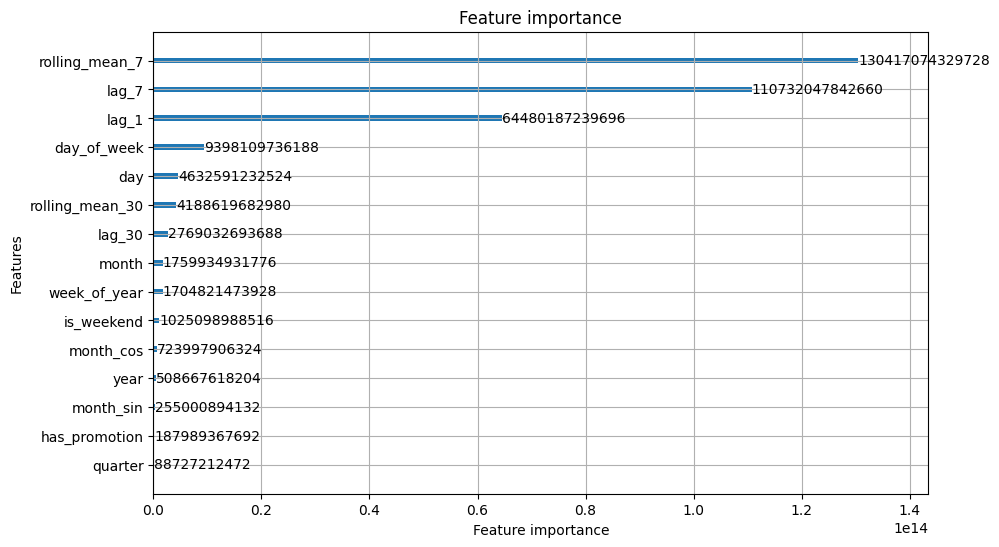

In [45]:
lgb.plot_importance(
    model_lgb,
    importance_type="gain",
    max_num_features=15,
    figsize=(10,6),
    precision=0
)

plt.savefig(
    "../images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

### Feature Importance

The feature importance analysis confirms the conclusions obtained during the exploratory data analysis.

The most influential predictor is **lag_7**, indicating that sales from the same weekday of the previous week contain the strongest predictive signal. This is consistent with the strong weekly seasonality observed during the EDA and explains why the Seasonal Naive baseline achieved competitive performance.

Historical sales features (`lag_7`, `lag_1`, `rolling_mean_30`, and `lag_30`) dominate the model, while calendar variables and promotion indicators contribute additional—but comparatively smaller—predictive power. This suggests that recent sales history is the primary driver of demand forecasting in this dataset.

In [46]:
prophet_train = train[["date", "sales", "has_promotion"]].copy()

prophet_train.rename(
    columns={
        "date": "ds",
        "sales": "y"
    },
    inplace=True
)

In [47]:
prophet_future = pd.concat(
    [
        val[["date", "has_promotion"]],
        test[["date", "has_promotion"]]
    ]
).copy()

prophet_future.rename(
    columns={
        "date": "ds"
    },
    inplace=True
)

In [48]:
prophet_predictions = []

prophet_metrics = []

families = sorted(family_daily["family"].unique())

print(f"Families to model: {families}")

Families to model: ['BEVERAGES', 'CLEANING', 'DAIRY', 'GROCERY I', 'PRODUCE']


In [49]:
for family in families:

    print(f"Training Prophet for {family}...")

    # -----------------------------
    # Split de la familia
    # -----------------------------
    train_family = train[
        train["family"] == family
    ].copy()

    val_family = val[
        val["family"] == family
    ].copy()

    test_family = test[
        test["family"] == family
    ].copy()

    # -----------------------------
    # Prophet necesita ds e y
    # -----------------------------
    prophet_train = train_family[
        ["date", "sales", "has_promotion"]
    ].rename(
        columns={
            "date": "ds",
            "sales": "y"
        }
    )

    future = pd.concat(
        [
            val_family,
            test_family
        ]
    )[
        ["date", "has_promotion"]
    ].rename(
        columns={
            "date": "ds"
        }
    )

    # -----------------------------
    # Modelo
    # -----------------------------
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative"
    )

    model.add_regressor("has_promotion")

    model.fit(prophet_train)

    forecast = model.predict(future)

    forecast["family"] = family

    prophet_predictions.append(forecast)
    


Training Prophet for BEVERAGES...


19:43:06 - cmdstanpy - INFO - Chain [1] start processing
19:43:06 - cmdstanpy - INFO - Chain [1] done processing
19:43:06 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for CLEANING...


19:43:07 - cmdstanpy - INFO - Chain [1] done processing
19:43:07 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for DAIRY...


19:43:07 - cmdstanpy - INFO - Chain [1] done processing
19:43:07 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for GROCERY I...


19:43:07 - cmdstanpy - INFO - Chain [1] done processing
19:43:08 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet for PRODUCE...


19:43:08 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
prophet_forecast = pd.concat(
    prophet_predictions,
    ignore_index=True
)

prophet_forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,extra_regressors_multiplicative,extra_regressors_multiplicative_lower,extra_regressors_multiplicative_upper,has_promotion,...,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat,family
0,2017-01-01,208803.604721,218667.687439,289831.637380,208803.604721,208803.604721,-0.232375,-0.232375,-0.232375,-0.232375,...,0.311975,0.311975,0.133052,0.133052,0.133052,0.0,0.0,0.0,253206.244968,BEVERAGES
1,2017-01-02,208748.479960,142028.646764,214892.678632,208748.479960,208748.479960,-0.232375,-0.232375,-0.232375,-0.232375,...,-0.032316,-0.032316,0.121227,0.121227,0.121227,0.0,0.0,0.0,178800.496900,BEVERAGES
2,2017-01-03,208693.355199,124513.061598,196721.588738,208693.355199,208693.355199,-0.232375,-0.232375,-0.232375,-0.232375,...,-0.102751,-0.102751,0.108757,0.108757,0.108757,0.0,0.0,0.0,161451.800142,BEVERAGES
3,2017-01-04,208638.230437,121428.975173,192950.930347,208638.230437,208638.230437,-0.232375,-0.232375,-0.232375,-0.232375,...,-0.101333,-0.101333,0.095807,0.095807,0.095807,0.0,0.0,0.0,159003.085674,BEVERAGES
4,2017-01-05,208583.105676,104965.517247,173458.574042,208583.105676,208583.105676,-0.232375,-0.232375,-0.232375,-0.232375,...,-0.180158,-0.180158,0.082544,0.082544,0.082544,0.0,0.0,0.0,139752.970671,BEVERAGES


In [51]:
actual_sales = pd.concat(
    [
        val,
        test
    ],
    ignore_index=True
)[
    ["date", "family", "sales"]
]

actual_sales.head()

,date,family,sales
0,2017-01-01,BEVERAGES,4008.0
1,2017-01-02,BEVERAGES,335235.0
2,2017-01-03,BEVERAGES,243422.0
3,2017-01-04,BEVERAGES,211239.0
4,2017-01-05,BEVERAGES,175975.0


In [52]:
prophet_results = actual_sales.merge(
    prophet_forecast[
        [
            "ds",
            "family",
            "yhat"
        ]
    ],
    left_on=["date", "family"],
    right_on=["ds", "family"]
)

prophet_results.head()

,date,family,sales,ds,yhat
0,2017-01-01,BEVERAGES,4008.0,2017-01-01,253206.244968
1,2017-01-02,BEVERAGES,335235.0,2017-01-02,178800.496900
2,2017-01-03,BEVERAGES,243422.0,2017-01-03,161451.800142
3,2017-01-04,BEVERAGES,211239.0,2017-01-04,159003.085674
4,2017-01-05,BEVERAGES,175975.0,2017-01-05,139752.970671


In [53]:
prophet_metrics = evaluate_model(
    "Prophet",
    prophet_results["sales"],
    prophet_results["yhat"]
)

Prophet
MAE : 27780.09
RMSE: 42223.21
R²  : 0.7461
-----------------------------------


### Prophet Results

Prophet was evaluated as an alternative forecasting approach using one independent model for each of the top five product families.

Although Prophet successfully captured the long-term trend and seasonality, its performance was considerably lower than LightGBM across all evaluation metrics.

This behavior is expected because the exploratory data analysis revealed that recent sales history (especially the 7-day lag) is the strongest predictor of future demand. LightGBM explicitly exploits these lag-based features, whereas Prophet primarily models trend and seasonality, making it less effective for this particular forecasting problem.

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "Prophet",
        "LightGBM"
    ],
    "MAE": [
        naive_results[0],
        seasonal_results[0],
        prophet_metrics[0],
        lgb_results[0]
    ],
    "RMSE": [
        naive_results[1],
        seasonal_results[1],
        prophet_metrics[1],
        lgb_results[1]
    ],
    "R²": [
        naive_results[2],
        seasonal_results[2],
        prophet_metrics[2],
        lgb_results[2]
    ]
})

comparison = comparison.sort_values("RMSE").reset_index(drop=True)

comparison

,Model,MAE,RMSE,R²
0,LightGBM,10041.816092,15175.758000,0.966833
1,Seasonal Naive,16692.201646,25335.033159,0.907562
2,Naive,24660.898287,34977.358757,0.823811
3,Prophet,27780.091114,42223.206975,0.746133


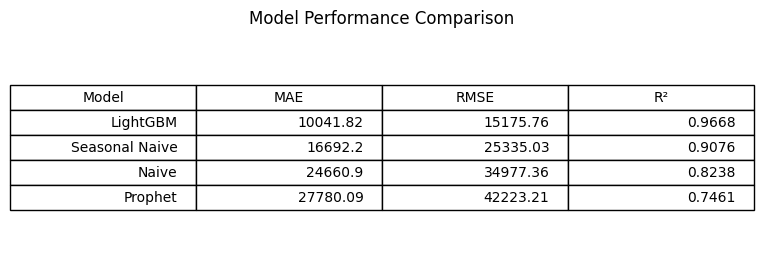

In [55]:
fig, ax = plt.subplots(figsize=(8, 2.5))

ax.axis("off")

table = ax.table(
    cellText=comparison.round({
        "MAE": 2,
        "RMSE": 2,
        "R²": 4
    }).values,
    colLabels=comparison.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Model Performance Comparison", pad=20)

plt.savefig(
    "../images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
comparison = comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4
})

comparison

,Model,MAE,RMSE,R²
0,LightGBM,10041.82,15175.76,0.9668
1,Seasonal Naive,16692.20,25335.03,0.9076
2,Naive,24660.90,34977.36,0.8238
3,Prophet,27780.09,42223.21,0.7461


### Why did Prophet underperform?

Although Prophet is a powerful forecasting model, it performed worse than both the Seasonal Naive baseline and the LightGBM model in this project.

This behavior is expected because the exploratory data analysis showed that recent sales history—particularly the 7-day lag—contains most of the predictive information. Prophet models long-term trend and seasonality but does not directly leverage lag features such as `lag_1`, `lag_7`, or rolling statistics.

In contrast, LightGBM explicitly learns from these historical patterns through engineered features, allowing it to capture short-term demand dynamics much more effectively. Therefore, Prophet's lower performance reflects the characteristics of this dataset rather than a limitation of the algorithm itself.

In [57]:
lightgbm_forecast = test.copy()

lightgbm_forecast["prediction"] = pred_lgb

lightgbm_forecast.head()

,date,family,sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,month_sin,month_cos,onpromotion,has_promotion,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,prediction
1578,2017-06-01,BEVERAGES,166771.0,2017,6,1,3,2,22,0,1.224647e-16,-1.0,586,1,174304.0,136779.0,200529.0,188653.857143,184453.266667,192416.984475
1579,2017-06-02,BEVERAGES,204402.0,2017,6,2,4,2,22,0,1.224647e-16,-1.0,1309,1,166771.0,212870.0,188754.0,192938.428571,183328.000000,168343.520769
1580,2017-06-03,BEVERAGES,278488.0,2017,6,3,5,2,22,1,1.224647e-16,-1.0,1377,1,204402.0,212127.0,149629.0,191728.714286,183849.600000,271117.777576
1581,2017-06-04,BEVERAGES,339352.0,2017,6,4,6,2,22,1,1.224647e-16,-1.0,1393,1,278488.0,254132.0,161279.0,201208.857143,188144.900000,291927.958014
1582,2017-06-05,BEVERAGES,214773.0,2017,6,5,0,2,23,0,1.224647e-16,-1.0,1253,1,339352.0,171962.0,233814.0,213383.142857,194080.666667,225109.594234


In [58]:
prophet_test = prophet_results[
    prophet_results["date"] >= test["date"].min()
].copy()

prophet_test.rename(
    columns={
        "yhat": "prediction"
    },
    inplace=True
)

prophet_test.head()

,date,family,sales,ds,prediction
755,2017-06-01,BEVERAGES,166771.0,2017-06-01,114404.873347
756,2017-06-02,BEVERAGES,204402.0,2017-06-02,132956.518710
757,2017-06-03,BEVERAGES,278488.0,2017-06-03,189169.163764
758,2017-06-04,BEVERAGES,339352.0,2017-06-04,212947.363286
759,2017-06-05,BEVERAGES,214773.0,2017-06-05,143783.990811


In [59]:
actual_daily = (
    test.groupby("date")["sales"]
        .sum()
        .reset_index()
)

In [60]:
lgb_daily = (
    lightgbm_forecast
    .groupby("date")["prediction"]
    .sum()
    .reset_index()
)

In [61]:
prophet_daily = (
    prophet_test
    .groupby("date")["prediction"]
    .sum()
    .reset_index()
)

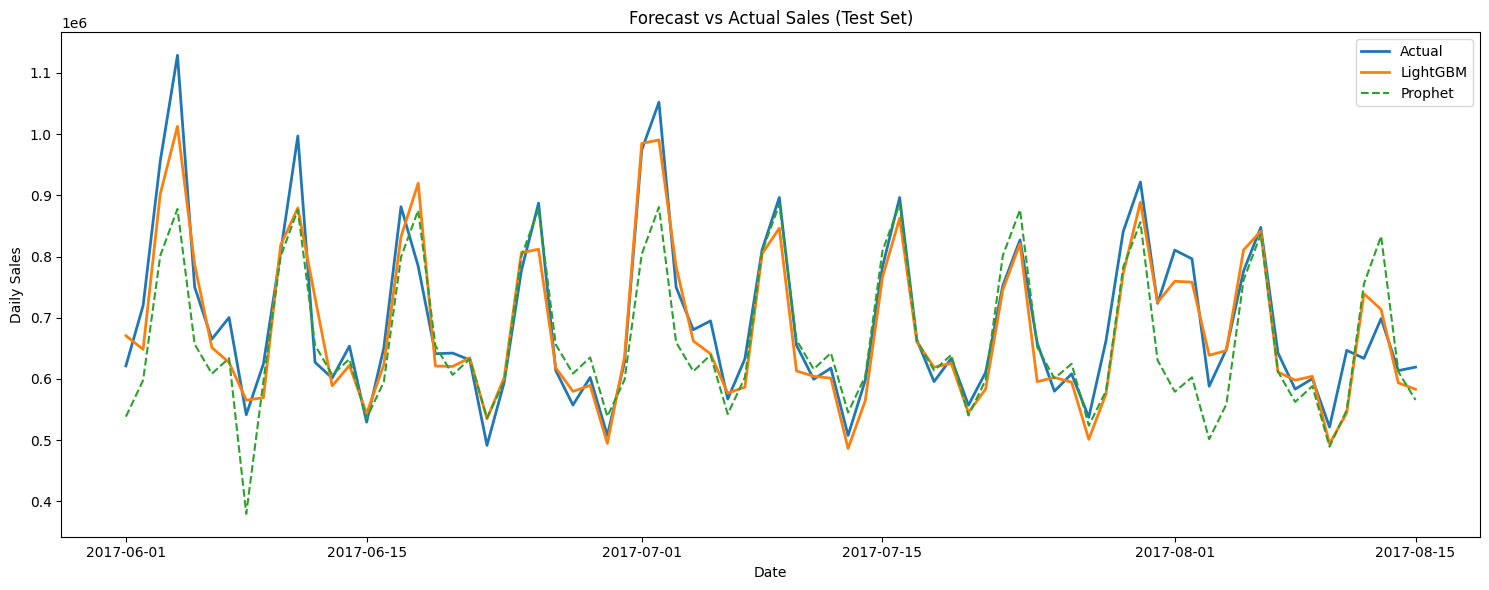

In [62]:
plt.figure(figsize=(15,6))

plt.plot(
    actual_daily["date"],
    actual_daily["sales"],
    label="Actual",
    linewidth=2
)

plt.plot(
    lgb_daily["date"],
    lgb_daily["prediction"],
    label="LightGBM",
    linewidth=2
)

plt.plot(
    prophet_daily["date"],
    prophet_daily["prediction"],
    label="Prophet",
    linestyle="--"
)

plt.title("Forecast vs Actual Sales (Test Set)")
plt.xlabel("Date")
plt.ylabel("Daily Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/forecast_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

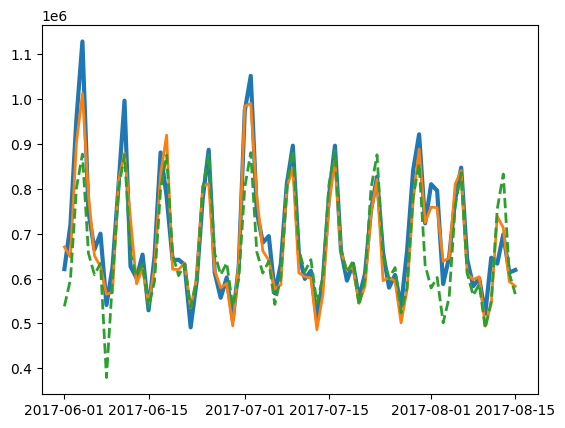

In [63]:
plt.plot(
    actual_daily["date"],
    actual_daily["sales"],
    label="Actual",
    linewidth=3
)

plt.plot(
    lgb_daily["date"],
    lgb_daily["prediction"],
    label="LightGBM",
    linewidth=2
)

plt.plot(
    prophet_daily["date"],
    prophet_daily["prediction"],
    label="Prophet",
    linestyle="--",
    linewidth=2
)

In [64]:
import joblib
import json
from pathlib import Path

In [65]:
models_path = Path("../models")

models_path.mkdir(
    parents=True,
    exist_ok=True
)

In [66]:
joblib.dump(
    model_lgb,
    models_path / "lightgbm_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [67]:
metadata = {
    "model": "LightGBM",

    "top_families": families,

    "features": FEATURES,

    "train_period": {
        "start": str(train["date"].min().date()),
        "end": str(train["date"].max().date())
    },

    "validation_period": {
        "start": str(val["date"].min().date()),
        "end": str(val["date"].max().date())
    },

    "test_period": {
        "start": str(test["date"].min().date()),
        "end": str(test["date"].max().date())
    },

    "metrics": {
        "MAE": round(lgb_results[0],2),
        "RMSE": round(lgb_results[1],2),
        "R2": round(lgb_results[2],4)
    }
}




In [68]:
with open(
    models_path / "model_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )

print("Metadata saved successfully.")

Metadata saved successfully.


In [69]:
predictions = test.copy()

predictions["prediction"] = pred_lgb

predictions["error"] = (
    predictions["sales"]
    - predictions["prediction"]
)

predictions.head()

,date,family,sales,year,month,day,day_of_week,quarter,week_of_year,is_weekend,...,month_cos,onpromotion,has_promotion,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,prediction,error
1578,2017-06-01,BEVERAGES,166771.0,2017,6,1,3,2,22,0,...,-1.0,586,1,174304.0,136779.0,200529.0,188653.857143,184453.266667,192416.984475,-25645.984475
1579,2017-06-02,BEVERAGES,204402.0,2017,6,2,4,2,22,0,...,-1.0,1309,1,166771.0,212870.0,188754.0,192938.428571,183328.000000,168343.520769,36058.479231
1580,2017-06-03,BEVERAGES,278488.0,2017,6,3,5,2,22,1,...,-1.0,1377,1,204402.0,212127.0,149629.0,191728.714286,183849.600000,271117.777576,7370.222424
1581,2017-06-04,BEVERAGES,339352.0,2017,6,4,6,2,22,1,...,-1.0,1393,1,278488.0,254132.0,161279.0,201208.857143,188144.900000,291927.958014,47424.041986
1582,2017-06-05,BEVERAGES,214773.0,2017,6,5,0,2,23,0,...,-1.0,1253,1,339352.0,171962.0,233814.0,213383.142857,194080.666667,225109.594234,-10336.594234


In [70]:
reports_path = Path("../reports")

reports_path.mkdir(
    parents=True,
    exist_ok=True
)

In [71]:
predictions.to_csv(
    reports_path / "predictions.csv",
    index=False
)

print("Predictions exported successfully.")

Predictions exported successfully.


# Modeling Conclusions

## Objective

The objective of this notebook was to develop and compare multiple forecasting approaches for predicting daily demand across the five highest-selling product families.

---

## Data Preparation

A temporal train/validation/test split was used to prevent data leakage.

Several time-series features were engineered, including:

- Lag features (1, 7 and 30 days)
- Rolling mean features (7 and 30 days)
- Calendar variables
- Cyclical month encoding
- Promotion indicator

These features were created independently for each product family.

---

## Model Evaluation

Four forecasting approaches were evaluated:

| Model | Summary |
|--------|---------|
| Naive | Uses previous day's sales as prediction |
| Seasonal Naive | Uses sales from the same weekday of the previous week |
| Prophet | Statistical forecasting model with trend and seasonality |
| LightGBM | Gradient boosting model using engineered time-series features |

LightGBM achieved the best performance across every evaluation metric.

The Seasonal Naive baseline also performed strongly, confirming the existence of a pronounced weekly seasonal pattern.

Prophet captured the overall trend but was unable to match the performance of LightGBM because it does not directly exploit lag-based information.

---

## Feature Importance

Feature importance analysis revealed that historical demand is the strongest predictor of future sales.

The most influential variables were:

1. lag_7
2. lag_1
3. rolling_mean_30

These findings are fully consistent with the exploratory data analysis performed in Notebook 01.

---

## Final Conclusion

The final LightGBM model achieved the lowest forecasting error while successfully capturing weekly demand patterns across all five product families.

This demonstrates that combining feature engineering with machine learning substantially improves forecasting accuracy over traditional statistical and baseline methods.

The trained model and prediction outputs have been exported for deployment and dashboard visualization in the next stage of the project.

In [72]:
# =====================================
# Create Feature Importance DataFrame
# =====================================

importance_df = pd.DataFrame({
    "Feature": model_lgb.feature_name(),
    "Importance": model_lgb.feature_importance(importance_type="gain")
})

# Convertir a porcentaje
importance_df["Importance"] = (
    importance_df["Importance"]
    / importance_df["Importance"].sum()
    * 100
)

importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df["Importance"] = importance_df["Importance"].round(1)

importance_df.head()

,Feature,Importance
0,rolling_mean_7,39.2
1,lag_7,33.3
2,lag_1,19.4
3,day_of_week,2.8
4,day,1.4


In [76]:
print(reports_path)
print(reports_path / "feature_importance.csv")

..\reports
..\reports\feature_importance.csv


In [79]:
from pathlib import Path

output = Path(r"C:\Users\PC\OneDrive\Escritorio\Analysis end to end\retail-demand-forecasting\data\dashboard\feature_importance.csv")

print(output)
print(output.exists())

importance_df.to_csv(output, index=False)

print("Guardado correctamente")
print(output.stat().st_mtime)

C:\Users\PC\OneDrive\Escritorio\Analysis end to end\retail-demand-forecasting\data\dashboard\feature_importance.csv
True
Guardado correctamente
1783993528.372854


In [78]:
print((reports_path / "feature_importance.csv").exists())

True


In [74]:
dashboard_predictions = predictions.copy()

dashboard_predictions["abs_error"] = dashboard_predictions["error"].abs()

dashboard_predictions["ape"] = (
    dashboard_predictions["abs_error"]
    / dashboard_predictions["sales"].replace(0, np.nan)
) * 100

dashboard_predictions["dataset"] = "Test"

dashboard_predictions.to_csv(
    reports_path / "test_predictions.csv",
    index=False
)

print("✓ test_predictions.csv exported")

✓ test_predictions.csv exported


In [75]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [
        lgb_results[0],
        lgb_results[1],
        lgb_results[2]
    ]
})

metrics_df.to_csv(
    reports_path / "model_metrics.csv",
    index=False
)

print("✓ model_metrics.csv exported")

✓ model_metrics.csv exported
